1. **Overall NHT type effect (Kruskal-Wallis):**

  * No significant difference across *specific NHT agents alone* (p = 0.545).
  * Interpretation: NHT type by itself does not explain time differences well.

2. **ADT agent effect (Kruskal-Wallis):**

  * Strongly significant (p = 0.00020).
  * Interpretation: ADT backbone therapy is a major driver of time variation.

3. **ADT × NHT interaction structure (Kruskal-Wallis across pairs):**

  * Significant overall effect (p = 0.00016).
  * Interpretation: The combination of ADT + NHT matters more than either alone.

4. **Pairwise comparisons (key pattern):**

  * Most comparisons = not significant after correction (many p = 1.0), suggesting sparse separation overall.
  * Some notable lower p-values:

    * Lupron → Darolutamide shows strongest evidence of difference vs several groups
    * Orgovyx → Darolutamide also shows some moderate evidence of differences in certain comparisons.
  * Overall: effects appear driven by a few specific combinations rather than widespread separation.

5. **Median/central tendency pattern (descriptive trend):**

  * Lower medians:

    * Orgovyx + Darolutamide (very low median ~15 days in one subgroup)
    * Orgovyx + Abiraterone (~29.5 days)
    * Firmagon + Abiraterone (~32.5–35.5 days)
  * Higher medians:

    * Lupron + Enzalutamide (~785 days)
    * Lupron + Darolutamide (~883 days)
    * Orgovyx + Darolutamide shows high variability with extreme outliers in some groups (up to ~1370+ days)
  * Interpretation: strong heterogeneity and skewed distributions across combinations.

6. **OLS regression (log_time model):**

  * Model is significant overall (F-test p ≈ 1.8e-05).
  * Moderate explanatory power (R² ≈ 0.24).
  * Key findings:

    * No single ADT or NHT main effect is strongly significant at 0.05 level.
    * Orgovyx shows a borderline negative association (p ≈ 0.094).
  * Interpretation: regression suggests weak-to-moderate global signal but no dominant independent predictors after adjustment.

7. **Overall interpretation across methods:**

  * NHT alone: not significant.
  * ADT backbone: strongly significant driver.
  * Interaction (ADT × NHT): important globally but driven by a small subset of combinations.
  * Data likely:

    * Highly imbalanced (many groups with n = 1–3)
    * Strongly right-skewed (long tail / extreme values)
    * Sensitive to small-sample noise in pairwise tests

In [25]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as sp


BASE_FILE = os.path.join(
    "..", "..", "data", "processed",
    "cardio_onc_prostate_06_broad_clean.csv"
)

df = pd.read_csv(BASE_FILE)
print("Raw shape:", df.shape)

Raw shape: (239, 60)


In [ ]:
def prepare_time_variable(df):
    df = df.copy()

    df["nht_start_date"] = pd.to_datetime(df["nht_start_date"], errors = "coerce")
    df["adt_start_date"] = pd.to_datetime(df["adt_start_date"], errors = "coerce")

    df["time_to_nht"] = (
            df["nht_start_date"] - df["adt_start_date"]
    ).dt.days

    return df


df = prepare_time_variable(df)

print(df["time_to_nht"].describe())


def clean_data(df):
    df_clean = df.copy()

    df_clean = df_clean[
        (df_clean["time_to_nht"].notna()) &
        (df_clean["time_to_nht"] >= 0) &
        (df_clean["specific_nht_used"].notna()) &
        (df_clean["adt_agent"].notna())
        ]

    # Remove extreme outliers (99th percentile)
    upper_cap = df_clean["time_to_nht"].quantile(0.99)
    df_clean = df_clean[df_clean["time_to_nht"] <= upper_cap]

    return df_clean


df_clean = clean_data(df)
print("Clean shape:", df_clean.shape)


def summarize_by_group(df, group_var):
    return (
        df.groupby(group_var)["time_to_nht"]
        .agg(["count", "mean", "median", "std"])
        .sort_values("median")
    )


print("\nNHT Summary:")
print(summarize_by_group(df_clean, "specific_nht_used"))

print("\nADT Summary:")
print(summarize_by_group(df_clean, "adt_agent"))

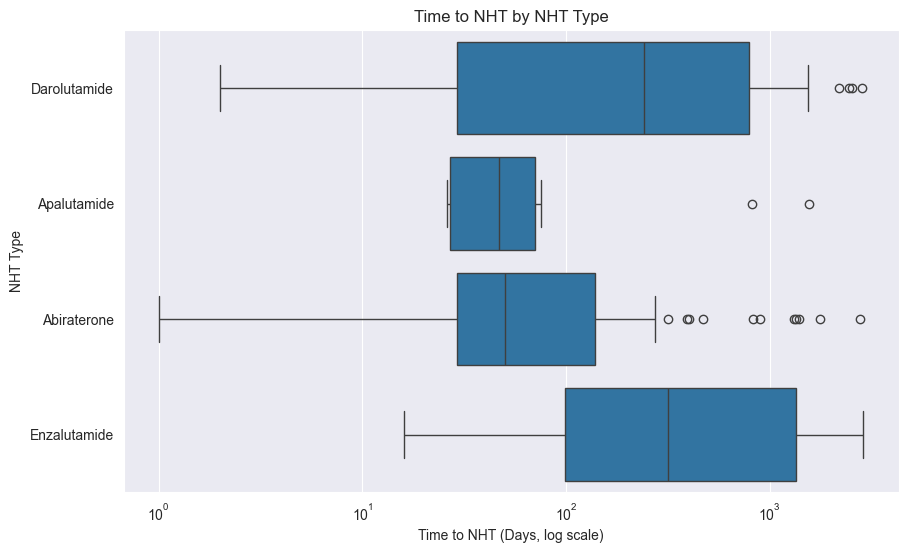

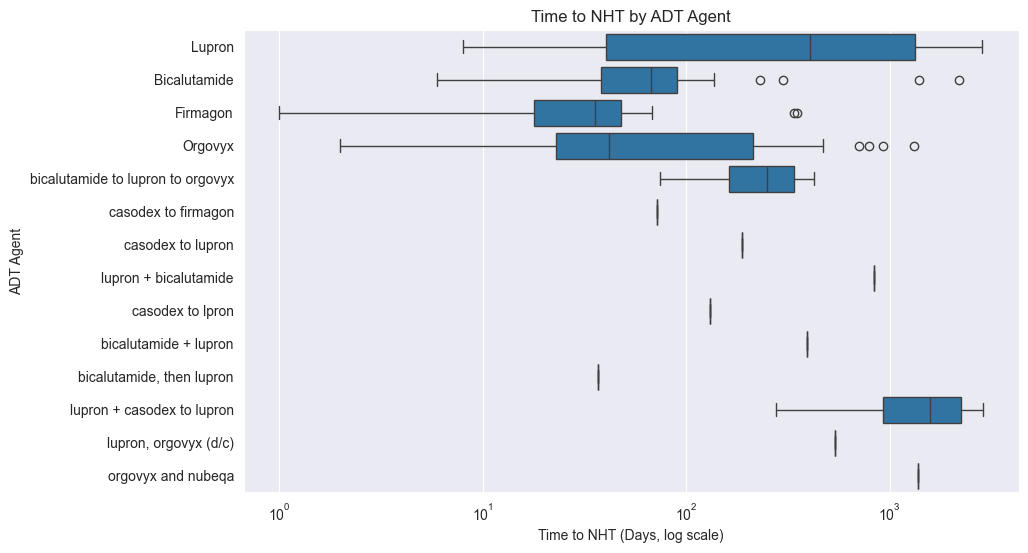

In [32]:
def plot_boxplots(df):
    df_plot = df[df["time_to_nht"] > 0]

    # NHT plot (horizontal)
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df_plot, y="specific_nht_used", x="time_to_nht")
    plt.xscale("log")
    plt.title("Time to NHT by NHT Type")
    plt.ylabel("NHT Type")
    plt.xlabel("Time to NHT (Days, log scale)")
    plt.show()

    # ADT plot (horizontal)
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df_plot, y="adt_agent", x="time_to_nht")
    plt.xscale("log")
    plt.title("Time to NHT by ADT Agent")
    plt.ylabel("ADT Agent")
    plt.xlabel("Time to NHT (Days, log scale)")
    plt.show()


plot_boxplots(df_clean)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


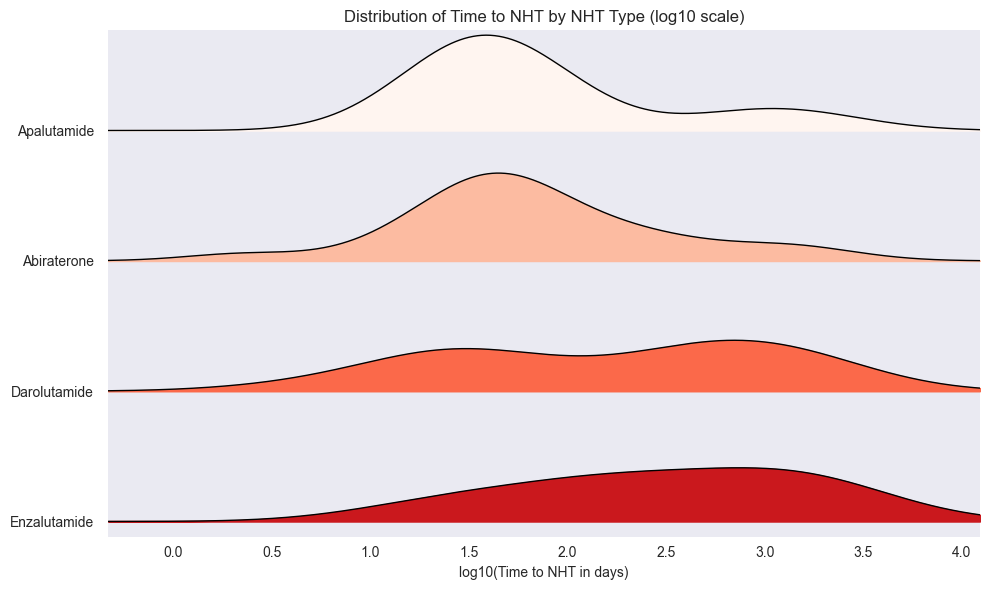

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


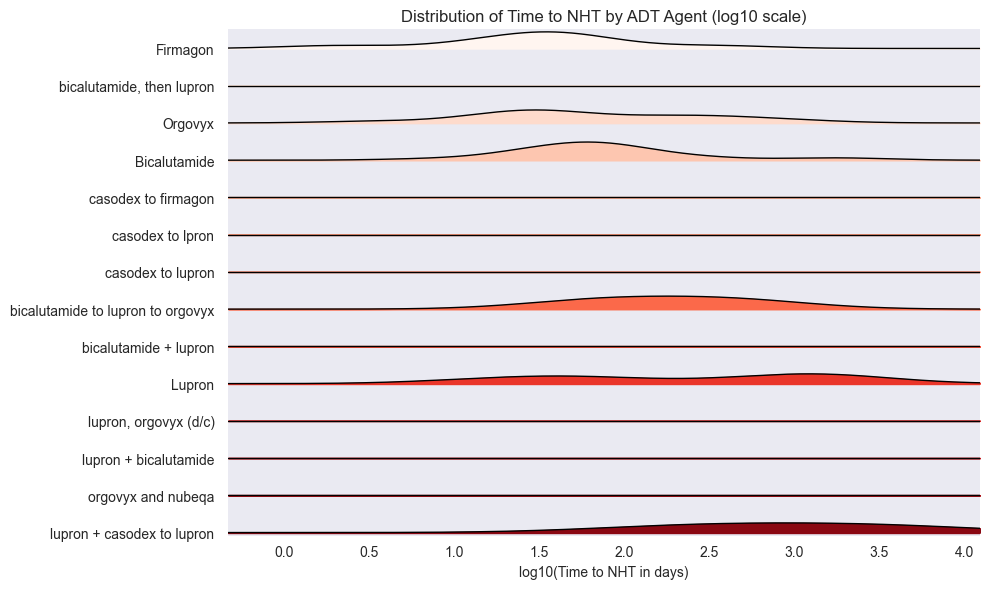

In [37]:
import joypy

def plot_ridgelines(df):
    df_plot = df[df["time_to_nht"] > 0].copy()

    # Log transform (better for skew)
    df_plot["log_time"] = np.log10(df_plot["time_to_nht"] + 1)

    # -----------------------------
    # NHT ORDERING (by median)
    # -----------------------------
    order_nht = (
        df_plot.groupby("specific_nht_used")["time_to_nht"]
        .median()
        .sort_values()
        .index
    )

    df_plot["specific_nht_used"] = pd.Categorical(
        df_plot["specific_nht_used"],
        categories=order_nht,
        ordered=True
    )

    df_plot = df_plot.sort_values("specific_nht_used")

    # -----------------------------
    # NHT RIDGELINE
    # -----------------------------
    joypy.joyplot(
        df_plot,
        by="specific_nht_used",
        column="log_time",
        overlap=1,
        figsize=(10, 6),
        colormap=plt.cm.Reds,
        linewidth=1
    )

    plt.title("Distribution of Time to NHT by NHT Type (log10 scale)")
    plt.xlabel("log10(Time to NHT in days)")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # ADT ORDERING
    # -----------------------------
    order_adt = (
        df_plot.groupby("adt_agent")["time_to_nht"]
        .median()
        .sort_values()
        .index
    )

    df_plot["adt_agent"] = pd.Categorical(
        df_plot["adt_agent"],
        categories=order_adt,
        ordered=True
    )

    df_plot = df_plot.sort_values("adt_agent")

    # -----------------------------
    # ADT RIDGELINE
    # -----------------------------
    joypy.joyplot(
        df_plot,
        by="adt_agent",
        column="log_time",
        overlap=1,
        figsize=(10, 6),
        colormap=plt.cm.Reds,
        linewidth=1
    )

    plt.title("Distribution of Time to NHT by ADT Agent (log10 scale)")
    plt.xlabel("log10(Time to NHT in days)")
    plt.tight_layout()
    plt.show()

plot_ridgelines(df_clean)


In [27]:
def kruskal_test(df, group_var):
    groups = [
        group["time_to_nht"].values
        for _, group in df.groupby(group_var)
    ]
    stat, p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis ({group_var}): p = {p:.5f}")


kruskal_test(df_clean, "specific_nht_used")
kruskal_test(df_clean, "adt_agent")

def compute_pair_summary(df):
    return (
        df.groupby(["adt_agent", "specific_nht_used"])["time_to_nht"]
        .agg(["count", "median", "mean", "std"])
        .reset_index()
    )


pair_summary = compute_pair_summary(df_clean)
print(pair_summary.sort_values("median"))

Kruskal-Wallis (specific_nht_used): p = 0.54545
Kruskal-Wallis (adt_agent): p = 0.00020
                            adt_agent specific_nht_used  count  median  \
13                            Orgovyx      Darolutamide     27    15.0   
12                            Orgovyx       Apalutamide      3    28.0   
11                            Orgovyx       Abiraterone     28    29.5   
14                            Orgovyx      Enzalutamide      7    31.0   
4                            Firmagon       Abiraterone     12    35.5   
5                            Firmagon       Apalutamide      2    36.5   
18          bicalutamide, then lupron       Abiraterone      1    37.0   
0                        Bicalutamide       Abiraterone     13    57.0   
7                              Lupron       Abiraterone     22    62.0   
1                        Bicalutamide       Apalutamide      3    66.0   
19                casodex to firmagon       Abiraterone      1    72.0   
17  bicalutamide to lupr

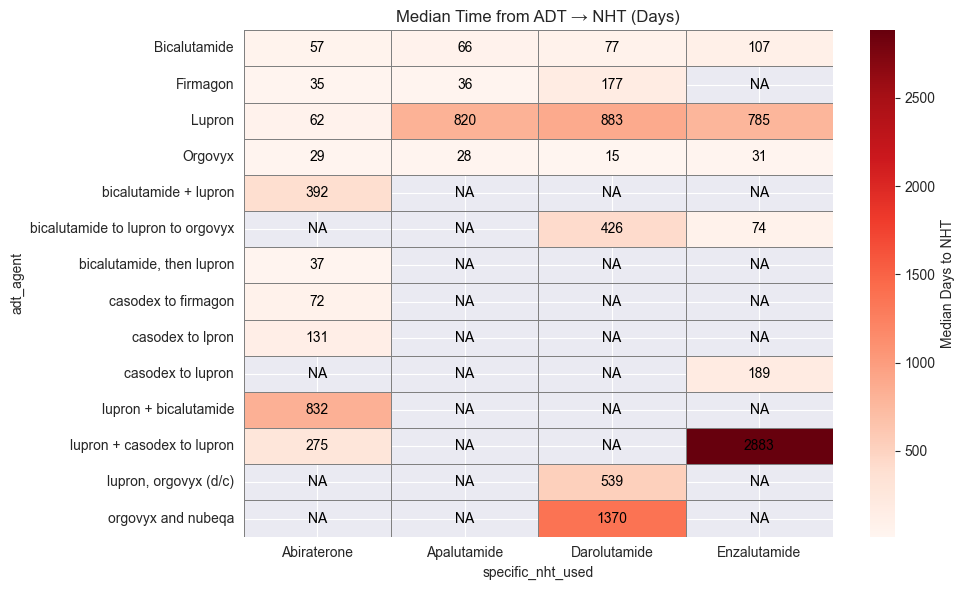

In [28]:
def plot_heatmap(pair_summary):
    heatmap_data = pair_summary.pivot(
        index = "adt_agent",
        columns = "specific_nht_used",
        values = "median"
    )

    mask = heatmap_data.isna()

    plt.figure(figsize = (10, 6))

    sns.heatmap(
        heatmap_data,
        mask = mask,
        cmap = "Reds",
        annot = False,
        linewidths = 0.5,
        linecolor = "gray",
        cbar_kws = {"label": "Median Days to NHT"}
    )

    # Manual annotations
    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            val = heatmap_data.iloc[i, j]

            if pd.isna(val):
                text = "NA"
            else:
                text = f"{int(val)}"

            plt.text(j + 0.5, i + 0.5, text,
                     ha = "center", va = "center", color = "black")

    plt.title("Median Time from ADT → NHT (Days)")
    plt.tight_layout()
    plt.show()


plot_heatmap(pair_summary)

In [29]:
def filter_valid_pairs(df, pair_summary, min_n = 5):
    valid_pairs = pair_summary[pair_summary["count"] >= min_n]

    df_valid = df.merge(
        valid_pairs[["adt_agent", "specific_nht_used"]],
        on = ["adt_agent", "specific_nht_used"],
        how = "inner"
    )

    return df_valid


df_valid = filter_valid_pairs(df_clean, pair_summary)

df_valid["adt_nht_pair"] = (
        df_valid["adt_agent"] + " → " + df_valid["specific_nht_used"]
)

groups = [
    g["time_to_nht"].values
    for _, g in df_valid.groupby("adt_nht_pair")
]

stat, p = stats.kruskal(*groups)
print(f"Kruskal across ADT–NHT pairs: p = {p:.5f}")

Kruskal across ADT–NHT pairs: p = 0.00016


In [30]:
posthoc = sp.posthoc_dunn(
    df_valid,
    val_col = "time_to_nht",
    group_col = "adt_nht_pair",
    p_adjust = "bonferroni"
)

print(posthoc)

                             Bicalutamide → Abiraterone  \
Bicalutamide → Abiraterone                          1.0   
Bicalutamide → Darolutamide                         1.0   
Firmagon → Abiraterone                              1.0   
Lupron → Abiraterone                                1.0   
Lupron → Darolutamide                               1.0   
Lupron → Enzalutamide                               1.0   
Orgovyx → Abiraterone                               1.0   
Orgovyx → Darolutamide                              1.0   
Orgovyx → Enzalutamide                              1.0   

                             Bicalutamide → Darolutamide  \
Bicalutamide → Abiraterone                      1.000000   
Bicalutamide → Darolutamide                     1.000000   
Firmagon → Abiraterone                          1.000000   
Lupron → Abiraterone                            1.000000   
Lupron → Darolutamide                           1.000000   
Lupron → Enzalutamide                           1

In [31]:
df_valid["log_time"] = np.log1p(df_valid["time_to_nht"])

model = smf.ols(
    "log_time ~ C(adt_agent) * C(specific_nht_used)",
    data = df_valid
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_time   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     5.056
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.82e-05
Time:                        23:14:42   Log-Likelihood:                -291.22
No. Observations:                 136   AIC:                             600.4
Df Residuals:                     127   BIC:                             626.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------